In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [10]:
# Project Setup #

import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/PersianSentimentProject"
)

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("Project Root:", PROJECT_ROOT)

Project Root: /content/drive/MyDrive/PersianSentimentProject


In [12]:
ui_matches = [
    path
    for path in PROJECT_ROOT.rglob("notebook_ui")
    if path.is_dir()
]

print("Matches:")

for path in ui_matches:
    print(path)

Matches:
/content/drive/MyDrive/PersianSentimentProject/notebooks/notebook_ui


In [14]:
NOTEBOOK_UI_PATH = ui_matches[0]

UI_PARENT = NOTEBOOK_UI_PATH.parent

if str(UI_PARENT) not in sys.path:
    sys.path.insert(
        0,
        str(UI_PARENT),
    )

os.chdir(UI_PARENT)

print("UI path:", NOTEBOOK_UI_PATH)
print("Working directory:", Path.cwd())

UI path: /content/drive/MyDrive/PersianSentimentProject/notebooks/notebook_ui
Working directory: /content/drive/MyDrive/PersianSentimentProject/notebooks


# Extended Analysis — ParsBERT vs Linear SVM

In this notebook, the final results of ParsBERT and the best classic model, Linear SVM , are analyzed in more detail.

**This notebook covers:**

- Detailed analysis of the Confusion Matrix of ParsBERT
- Identifying sentiment classes that ParsBERT confuses more frequently
- Manual review of real model errors
- Comparing ParsBERT and Linear SVM with different training data sizes
- Plotting Macro F1 performance based on training data size


## Extended Analysis List

- STEP 01 — Extended Analysis Setup
- STEP 02 — ParsBERT Confusion Matrix Analysis
- STEP 03 — Most Frequent Class Confusions
- STEP 04 — Manual Error Review
- STEP 05 — Learning Curve Data Preparation
- STEP 06 — Linear SVM Learning Curve
- STEP 07 — ParsBERT Learning Curve
- STEP 08 — Learning Curve Comparison
- STEP 09 — Final Extended Findings
- Conclusion

## STEP 01 — Extended Analysis Setup

Loading fixed splits and existing ParsBERT and Linear SVM outputs from previous experiments.


In [4]:
# Imports #

import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [65]:
# Paths #

SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "sentipers_parsbert_split_v1.csv"
)

PARSBERT_PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "04_parsbert"
    / "predictions"
    / "test_predictions.csv"
)

CLASSIC_PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "03_classic_models"
    / "error_analysis_table.csv"
)

PARSBERT_METRICS_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "04_parsbert"
    / "metrics"
    / "test_metrics.json"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "05_extended_analysis"
)

TABLES_DIR = OUTPUT_DIR / "tables"
PLOTS_DIR = OUTPUT_DIR / "plots"

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [6]:
split_df = pd.read_csv(
    SPLIT_PATH
)

parsbert_predictions = pd.read_csv(
    PARSBERT_PREDICTIONS_PATH
)

classic_predictions = pd.read_csv(
    CLASSIC_PREDICTIONS_PATH
)

In [7]:
# Dataset Split Summary #

split_df[
    "split"
].value_counts()

,count
split,
train,9165
test,2619
validation,1310


## STEP 02 — ParsBERT Confusion Matrix Analysis

Detailed investigation of model errors on the Test Set.


In [24]:
# ParsBERT Confusion Matrix #

POLARITIES = [-2, -1, 0, 1, 2]

CLASS_NAMES = [
    "furious",
    "angry",
    "neutral",
    "happy",
    "delighted",
]

y_true = parsbert_predictions[
    "polarity"
]

y_pred = parsbert_predictions[
    "predicted_polarity"
]


cm = confusion_matrix(
    y_true,
    y_pred,
    labels=POLARITIES,
)


cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
)

cm_df

,furious,angry,neutral,happy,delighted
furious,4,21,7,4,1
angry,0,179,69,24,3
neutral,1,59,764,147,21
happy,0,22,157,489,166
delighted,0,6,7,78,390


In [25]:
# Normalized Confusion Matrix #

cm_percent = (
    cm
    / cm.sum(
        axis=1,
        keepdims=True,
    )
    * 100
)


cm_percent_df = pd.DataFrame(
    cm_percent,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
).round(2)

cm_percent_df

,furious,angry,neutral,happy,delighted
furious,10.81,56.76,18.92,10.81,2.70
angry,0.00,65.09,25.09,8.73,1.09
neutral,0.10,5.95,77.02,14.82,2.12
happy,0.00,2.64,18.82,58.63,19.90
delighted,0.00,1.25,1.46,16.22,81.08


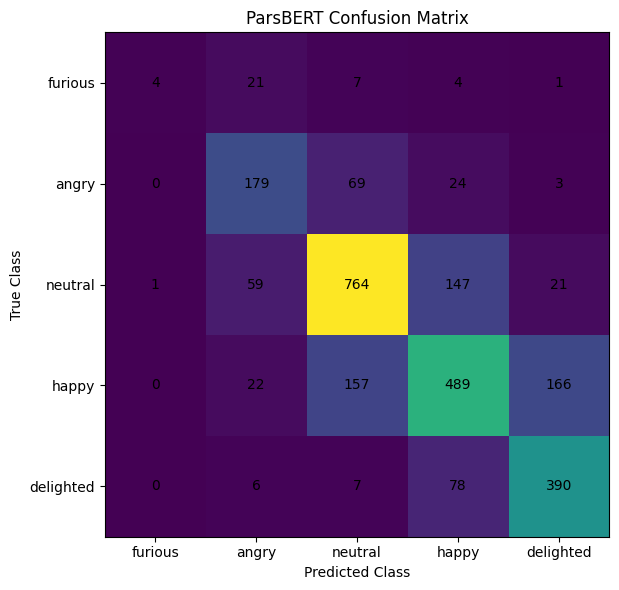

In [26]:
# Confusion Matrix Plot #

fig, ax = plt.subplots(
    figsize=(8, 6)
)

image = ax.imshow(
    cm
)

ax.set_xticks(
    range(len(CLASS_NAMES))
)

ax.set_yticks(
    range(len(CLASS_NAMES))
)

ax.set_xticklabels(
    CLASS_NAMES
)

ax.set_yticklabels(
    CLASS_NAMES
)


for i in range(len(CLASS_NAMES)):

    for j in range(len(CLASS_NAMES)):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )


ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)

ax.set_title(
    "ParsBERT Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [5]:
# Save Confusion Matrix Results #

cm_df.to_csv(
    TABLES_DIR
    / "parsbert_confusion_matrix.csv"
)

cm_percent_df.to_csv(
    TABLES_DIR
    / "parsbert_confusion_matrix_percent.csv"
)

fig.savefig(
    PLOTS_DIR
    / "parsbert_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight",
)

NameError: name 'cm_df' is not defined

## STEP 03 — Most Frequent Class Confusions

Identifying sentiment class pairs that ParsBERT confuses most frequently.


In [32]:
# Directed Class Confusions #

directed_confusions = []

for true_idx, true_class in enumerate(CLASS_NAMES):

    for pred_idx, predicted_class in enumerate(CLASS_NAMES):

        if true_idx == pred_idx:
            continue

        directed_confusions.append({
            "True Class": true_class,
            "Predicted Class": predicted_class,
            "Count": int(cm[true_idx, pred_idx]),
            "True Class (%)": round(
                cm_percent[true_idx, pred_idx],
                2,
            ),
        })


directed_confusions_df = pd.DataFrame(
    directed_confusions
).sort_values(
    "Count",
    ascending=False,
).reset_index(
    drop=True
)

directed_confusions_df

,True Class,Predicted Class,Count,True Class (%)
0,happy,delighted,166,19.90
1,happy,neutral,157,18.82
2,neutral,happy,147,14.82
3,delighted,happy,78,16.22
4,angry,neutral,69,25.09
5,neutral,angry,59,5.95
6,angry,happy,24,8.73
7,happy,angry,22,2.64
8,neutral,delighted,21,2.12
9,furious,angry,21,56.76


In [33]:
# Bidirectional Class Confusions #

pair_confusions = []

for i in range(len(CLASS_NAMES)):

    for j in range(i + 1, len(CLASS_NAMES)):

        forward = int(
            cm[i, j]
        )

        backward = int(
            cm[j, i]
        )

        pair_confusions.append({
            "Class A": CLASS_NAMES[i],
            "Class B": CLASS_NAMES[j],
            "A → B": forward,
            "B → A": backward,
            "Total Confusions": forward + backward,
        })


pair_confusions_df = pd.DataFrame(
    pair_confusions
).sort_values(
    "Total Confusions",
    ascending=False,
).reset_index(
    drop=True
)

pair_confusions_df

,Class A,Class B,A → B,B → A,Total Confusions
0,neutral,happy,147,157,304
1,happy,delighted,166,78,244
2,angry,neutral,69,59,128
3,angry,happy,24,22,46
4,neutral,delighted,21,7,28
5,furious,angry,21,0,21
6,angry,delighted,3,6,9
7,furious,neutral,7,1,8
8,furious,happy,4,0,4
9,furious,delighted,1,0,1


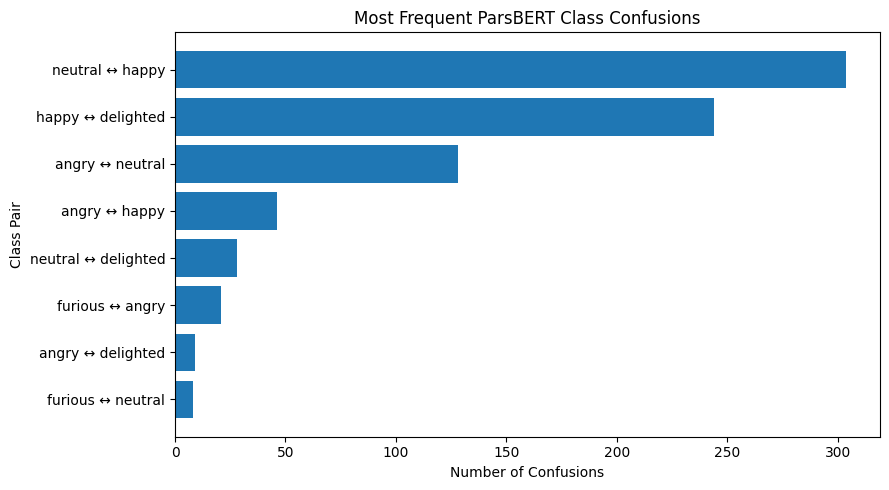

In [34]:
# Top Confusion Pairs Plot #

top_pairs = (
    pair_confusions_df
    .head(8)
    .copy()
)

top_pairs["Pair"] = (
    top_pairs["Class A"]
    + " ↔ "
    + top_pairs["Class B"]
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.barh(
    top_pairs["Pair"],
    top_pairs["Total Confusions"],
)

ax.invert_yaxis()

ax.set_xlabel(
    "Number of Confusions"
)

ax.set_ylabel(
    "Class Pair"
)

ax.set_title(
    "Most Frequent ParsBERT Class Confusions"
)

plt.tight_layout()
plt.show()

In [35]:
# Save Class Confusion Results #

directed_confusions_df.to_csv(
    TABLES_DIR
    / "parsbert_directed_confusions.csv",
    index=False,
)

pair_confusions_df.to_csv(
    TABLES_DIR
    / "parsbert_class_pair_confusions.csv",
    index=False,
)

fig.savefig(
    PLOTS_DIR
    / "parsbert_top_class_confusions.png",
    dpi=200,
    bbox_inches="tight",
)

## STEP 04 — Manual Error Review

Reviewing real prediction errors to understand model limitations.


In [37]:
# ParsBERT Misclassified Samples #

POLARITY_TO_CLASS = {
    -2: "furious",
    -1: "angry",
     0: "neutral",
     1: "happy",
     2: "delighted",
}


error_df = parsbert_predictions[
    parsbert_predictions["polarity"]
    != parsbert_predictions["predicted_polarity"]
].copy()


error_df["True Class"] = (
    error_df["polarity"]
    .map(POLARITY_TO_CLASS)
)

error_df["Predicted Class"] = (
    error_df["predicted_polarity"]
    .map(POLARITY_TO_CLASS)
)

error_df["Confusion"] = (
    error_df["True Class"]
    + " → "
    + error_df["Predicted Class"]
)


print(
    "Total ParsBERT Errors:",
    len(error_df),
)

Total ParsBERT Errors: 793


In [38]:
# Select 20 Representative Errors #

top_confusions = (
    directed_confusions_df
    .head(5)
)


selected_errors = []

for _, row in top_confusions.iterrows():

    confusion_name = (
        row["True Class"]
        + " → "
        + row["Predicted Class"]
    )

    samples = (
        error_df[
            error_df["Confusion"]
            == confusion_name
        ]
        .sample(
            n=min(
                4,
                len(
                    error_df[
                        error_df["Confusion"]
                        == confusion_name
                    ]
                ),
            ),
            random_state=SEED,
        )
    )

    selected_errors.append(
        samples
    )


manual_errors_df = pd.concat(
    selected_errors,
    ignore_index=True,
)

In [39]:
# Manual Error Review Table #

manual_review_df = manual_errors_df[
    [
        "text",
        "True Class",
        "Predicted Class",
        "confidence",
        "Confusion",
    ]
].copy()


manual_review_df.insert(
    0,
    "Sample",
    range(
        1,
        len(manual_review_df) + 1,
    ),
)


manual_review_df

,Sample,text,True Class,Predicted Class,confidence,Confusion
0,1,به جرئت میگم در حال حاضر این قدرتمندترین دستگا...,happy,delighted,0.917358,happy → delighted
1,2,cpuدوهسته ای 1گیگا هرتز، gpu adreno203 وظاهرش ...,happy,delighted,0.836763,happy → delighted
2,3,لپ تاپ خیلی خوبیه ایراد خاصی ندارد .,happy,delighted,0.526840,happy → delighted
3,4,بعلاوه توانایی فیلم برداری HD نیز با آن همراه ...,happy,delighted,0.853134,happy → delighted
4,5,این دوربین توانایی ضبط ویدیویی 1080p Full HD ر...,happy,neutral,0.921174,happy → neutral
5,6,اگر بافت غنی و واضح تصاویر فول اچ دی را تجربه ...,happy,neutral,0.792310,happy → neutral
6,7,در قسمت جلو و پشت گوشی دو لایه از شیشه ضد خش G...,happy,neutral,0.984276,happy → neutral
7,8,(با یک کاور حل میشه!,happy,neutral,0.970490,happy → neutral
8,9,از لحاظ کیفیت اسکرین و تراکم پیکسلی ان واقعا چ...,neutral,happy,0.645781,neutral → happy
9,10,نکته ی مهمی که باید در انتخاب یک گوشی در نظر د...,neutral,happy,0.968218,neutral → happy


In [40]:
# Save Manual Error Samples #

MANUAL_ERRORS_PATH = (
    TABLES_DIR
    / "parsbert_manual_20_errors.csv"
)


manual_review_df.to_csv(
    MANUAL_ERRORS_PATH,
    index=False,
)


print(
    "Saved:",
    MANUAL_ERRORS_PATH,
)

Saved: /content/drive/MyDrive/PersianSentimentProject/outputs/05_extended_analysis/tables/parsbert_manual_20_errors.csv


## STEP 05 — Learning Curve Data Preparation

Preparing training-size experiments for comparing model performance under different amounts of data.


In [42]:
# Fixed Dataset Splits #

train_pool = (
    split_df[
        split_df["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_df = (
    split_df[
        split_df["split"] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    split_df[
        split_df["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)


print("Train:", len(train_pool))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Train: 9165
Validation: 1310
Test: 2619


In [45]:
# Stratified Training Order #

rng = np.random.default_rng(
    SEED
)

train_pool["_random"] = rng.random(
    len(train_pool)
)

train_pool = (
    train_pool
    .sort_values(
        [
            "label_id",
            "_random",
        ]
    )
    .reset_index(drop=True)
)


train_pool["_class_rank"] = (
    train_pool
    .groupby("label_id")
    .cumcount()
    + 1
)

train_pool["_class_size"] = (
    train_pool
    .groupby("label_id")["label_id"]
    .transform("size")
)

In [46]:
# Learning Curve Subsets #

TRAIN_FRACTIONS = [
    0.20,
    0.40,
    0.60,
    0.80,
    1.00,
]


LEARNING_CURVE_DIR = (
    OUTPUT_DIR
    / "learning_curve"
)

LEARNING_CURVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


training_subsets = {}
subset_summary = []


for fraction in TRAIN_FRACTIONS:

    class_limit = np.ceil(
        train_pool["_class_size"]
        * fraction
    ).astype(int)

    subset = (
        train_pool[
            train_pool["_class_rank"]
            <= class_limit
        ]
        .drop(
            columns=[
                "_random",
                "_class_rank",
                "_class_size",
            ]
        )
        .copy()
        .reset_index(drop=True)
    )

    percent = int(
        fraction * 100
    )

    training_subsets[
        percent
    ] = subset

    subset.to_csv(
        LEARNING_CURVE_DIR
        / f"train_{percent}.csv",
        index=False,
    )

    subset_summary.append({
        "Train Percentage": percent,
        "Samples": len(subset),
        "Actual Percentage": round(
            len(subset)
            / len(train_pool)
            * 100,
            2,
        ),
    })

In [47]:
# Training Subset Summary #

subset_summary_df = pd.DataFrame(
    subset_summary
)

subset_summary_df

,Train Percentage,Samples,Actual Percentage
0,20,1835,20.02
1,40,3668,40.02
2,60,5501,60.02
3,80,7334,80.02
4,100,9165,100.00


In [49]:
# Class Distribution by Training Size #

class_distribution = []

for percent, subset in training_subsets.items():

    counts = (
        subset["label_id"]
        .value_counts()
        .sort_index()
    )

    for label_id, count in counts.items():

        class_distribution.append({
            "Train Percentage": percent,
            "Label ID": label_id,
            "Samples": count,
        })


class_distribution_df = pd.DataFrame(
    class_distribution
)

class_distribution_df

,Train Percentage,Label ID,Samples
0,20,0,26
1,20,1,193
2,20,2,695
3,20,3,584
4,20,4,337
5,40,0,52
6,40,1,386
7,40,2,1389
8,40,3,1168
9,40,4,673


In [50]:
# Save Learning Curve Dataset Summary #

subset_summary_df.to_csv(
    TABLES_DIR
    / "learning_curve_train_sizes.csv",
    index=False,
)

class_distribution_df.to_csv(
    TABLES_DIR
    / "learning_curve_class_distribution.csv",
    index=False,
)

## STEP 06 — Linear SVM Learning Curve

Measuring Linear SVM performance changes with different training dataset sizes.


In [52]:
# Load Linear SVM Pipeline #

import joblib

from sklearn.base import clone


SVM_MODEL_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "models"
    / "03_classic_models"
    / "linear_svm.joblib"
)


svm_template = joblib.load(
    SVM_MODEL_PATH
)

print(svm_template)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.98,
                                 max_features=50000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier',
                 LinearSVC(class_weight='balanced', dual=True, max_iter=5000,
                           random_state=42))])


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [53]:
X_test = test_df[
    "text"
]

y_test = test_df[
    "polarity"
]

In [54]:
# Train Linear SVM #

svm_results = []


for percent in [
    20,
    40,
    60,
    80,
    100,
]:

    train_subset = training_subsets[
        percent
    ]

    X_train = train_subset[
        "text"
    ]

    y_train = train_subset[
        "polarity"
    ]


    model = clone(
        svm_template
    )

    model.fit(
        X_train,
        y_train,
    )


    y_pred = model.predict(
        X_test
    )


    svm_results.append({
        "Train Percentage": percent,
        "Train Samples": len(train_subset),
        "Accuracy": accuracy_score(
            y_test,
            y_pred,
        ),
        "Macro F1": f1_score(
            y_test,
            y_pred,
            average="macro",
        ),
        "Weighted F1": f1_score(
            y_test,
            y_pred,
            average="weighted",
        ),
    })


    print(
        f"{percent}% completed"
    )

20% completed
40% completed
60% completed
80% completed
100% completed


In [55]:
# Linear SVM Results #

svm_learning_curve_df = pd.DataFrame(
    svm_results
)


svm_learning_curve_df[
    [
        "Accuracy",
        "Macro F1",
        "Weighted F1",
    ]
] = svm_learning_curve_df[
    [
        "Accuracy",
        "Macro F1",
        "Weighted F1",
    ]
].round(4)


svm_learning_curve_df

,Train Percentage,Train Samples,Accuracy,Macro F1,Weighted F1
0,20,1835,0.5300,0.4027,0.5227
1,40,3668,0.5731,0.4506,0.5663
2,60,5501,0.5884,0.4677,0.5816
3,80,7334,0.6029,0.5132,0.5980
4,100,9165,0.6025,0.4898,0.5978


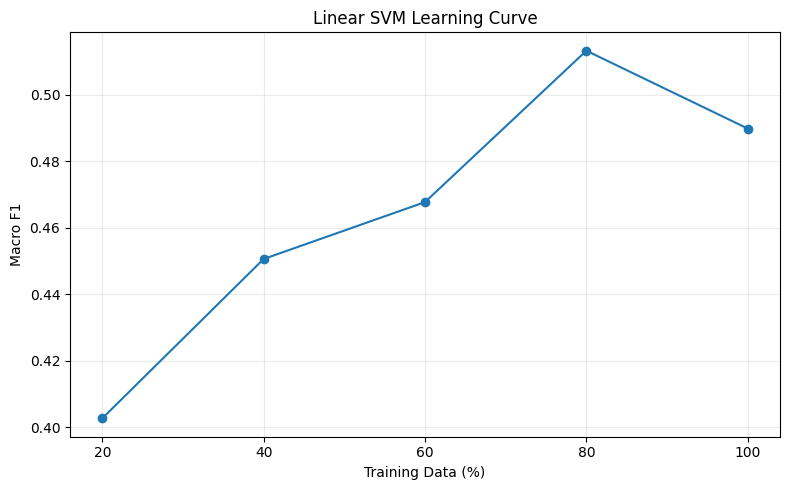

In [56]:
# Linear SVM Learning Curve Plot #

fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.plot(
    svm_learning_curve_df[
        "Train Percentage"
    ],
    svm_learning_curve_df[
        "Macro F1"
    ],
    marker="o",
)


ax.set_xlabel(
    "Training Data (%)"
)

ax.set_ylabel(
    "Macro F1"
)

ax.set_title(
    "Linear SVM Learning Curve"
)

ax.set_xticks(
    [
        20,
        40,
        60,
        80,
        100,
    ]
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [57]:
# Save Linear SVM Learning Curve #

svm_learning_curve_df.to_csv(
    TABLES_DIR
    / "svm_learning_curve.csv",
    index=False,
)


fig.savefig(
    PLOTS_DIR
    / "svm_learning_curve.png",
    dpi=200,
    bbox_inches="tight",
)

## STEP 07 — ParsBERT Learning Curve

Evaluating how ParsBERT performance changes when trained with different amounts of labeled data.


In [59]:
# ParsBERT Setup #

import inspect
import shutil
import torch

from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)


MODEL_NAME = (
    "HooshvareLab/bert-base-parsbert-uncased"
)

MAX_LENGTH = 128

TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 2

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 3


ID_TO_NAME = {
    0: "furious",
    1: "angry",
    2: "neutral",
    3: "happy",
    4: "delighted",
}

NAME_TO_ID = {
    value: key
    for key, value in ID_TO_NAME.items()
}


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [60]:
# Tokenizer and Dataset #

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


class SentimentDataset(Dataset):

    def __init__(self, dataframe):

        self.texts = (
            dataframe["text"]
            .astype(str)
            .tolist()
        )

        self.labels = (
            dataframe["label_id"]
            .astype(int)
            .tolist()
        )

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, index):

        encoded = tokenizer(
            self.texts[index],
            truncation=True,
            max_length=MAX_LENGTH,
            padding=False,
        )

        encoded["labels"] = (
            self.labels[index]
        )

        return encoded


data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
)

config.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

In [61]:
# Fixed Validation and Test Sets #

validation_dataset = SentimentDataset(
    validation_df
)

test_dataset = SentimentDataset(
    test_df
)

In [62]:
# Evaluation Metrics #

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1,
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
        ),
        "weighted_f1": f1_score(
            labels,
            predictions,
            average="weighted",
        ),
    }

In [63]:
# Train ParsBERT Learning Curve #

parsbert_results = []


for percent in [
    20,
    40,
    60,
    80,
]:

    print(
        f"\n===== Training {percent}% ====="
    )

    train_subset = training_subsets[
        percent
    ]

    train_dataset = SentimentDataset(
        train_subset
    )


    model = (
        AutoModelForSequenceClassification
        .from_pretrained(
            MODEL_NAME,
            num_labels=5,
            id2label=ID_TO_NAME,
            label2id=NAME_TO_ID,
        )
    )


    temp_output_dir = (
        f"/content/parsbert_learning_curve_{percent}"
    )


    training_kwargs = {
        "output_dir": temp_output_dir,
        "num_train_epochs": NUM_EPOCHS,
        "per_device_train_batch_size": TRAIN_BATCH_SIZE,
        "per_device_eval_batch_size": EVAL_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "fp16": True,
        "logging_steps": 50,
        "save_strategy": "epoch",
        "save_total_limit": 1,
        "load_best_model_at_end": True,
        "metric_for_best_model": "macro_f1",
        "greater_is_better": True,
        "report_to": "none",
        "seed": SEED,
        "data_seed": SEED,
    }


    signature = inspect.signature(
        TrainingArguments.__init__
    )

    if "eval_strategy" in signature.parameters:

        training_kwargs[
            "eval_strategy"
        ] = "epoch"

    else:

        training_kwargs[
            "evaluation_strategy"
        ] = "epoch"


    training_args = TrainingArguments(
        **training_kwargs
    )


    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )


    trainer.train()


    test_result = trainer.predict(
        test_dataset
    )


    test_metrics = compute_metrics(
        (
            test_result.predictions,
            test_result.label_ids,
        )
    )


    parsbert_results.append({
        "Train Percentage": percent,
        "Train Samples": len(train_subset),
        "Accuracy": test_metrics["accuracy"],
        "Macro F1": test_metrics["macro_f1"],
        "Weighted F1": test_metrics["weighted_f1"],
    })


    del trainer
    del model

    torch.cuda.empty_cache()

    shutil.rmtree(
        temp_output_dir,
        ignore_errors=True,
    )


    print(
        f"{percent}% completed — "
        f"Macro F1: "
        f"{test_metrics['macro_f1']:.4f}"
    )


===== Training 20% =====


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  654MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  654MB            

model.safetensors: downloading bytes:           |  0.00B            

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.489985,0.771566,0.692366,0.551460,0.687840
2,1.095298,0.788088,0.688550,0.588019,0.686357
3,0.826022,0.856650,0.694656,0.589632,0.692228


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

80% completed — Macro F1: 0.5969


In [66]:
# Add Existing 100 Percent Result #

with open(
    PARSBERT_METRICS_PATH,
    "r",
    encoding="utf-8",
) as file:

    full_parsbert_metrics = json.load(
        file
    )


parsbert_results.append({
    "Train Percentage": 100,
    "Train Samples": len(
        training_subsets[100]
    ),
    "Accuracy": full_parsbert_metrics[
        "accuracy"
    ],
    "Macro F1": full_parsbert_metrics[
        "macro_f1"
    ],
    "Weighted F1": full_parsbert_metrics[
        "weighted_f1"
    ],
})

In [67]:
# ParsBERT Learning Curve Results #

parsbert_learning_curve_df = (
    pd.DataFrame(
        parsbert_results
    )
    .sort_values(
        "Train Percentage"
    )
    .reset_index(
        drop=True
    )
)


parsbert_learning_curve_df[
    [
        "Accuracy",
        "Macro F1",
        "Weighted F1",
    ]
] = parsbert_learning_curve_df[
    [
        "Accuracy",
        "Macro F1",
        "Weighted F1",
    ]
].round(4)


parsbert_learning_curve_df

,Train Percentage,Train Samples,Accuracy,Macro F1,Weighted F1
0,20,1835,0.6415,0.5063,0.6392
1,40,3668,0.6651,0.5228,0.6595
2,60,5501,0.6907,0.5446,0.6858
3,80,7334,0.6999,0.5969,0.6958
4,100,9165,0.6972,0.5896,0.6920


In [ ]:
# Save ParsBERT Learning Curve #

parsbert_learning_curve_df.to_csv(
    TABLES_DIR
    / "parsbert_learning_curve.csv",
    index=False,
)

## STEP 08 — Learning Curve Comparison

Comparing the data efficiency and performance growth of ParsBERT and Linear SVM.


In [69]:
# Learning Curve Comparison #

comparison_df = pd.merge(
    svm_learning_curve_df[
        [
            "Train Percentage",
            "Train Samples",
            "Macro F1",
        ]
    ],
    parsbert_learning_curve_df[
        [
            "Train Percentage",
            "Macro F1",
        ]
    ],
    on="Train Percentage",
    suffixes=(
        " SVM",
        " ParsBERT",
    ),
)


comparison_df["F1 Improvement"] = (
    comparison_df["Macro F1 ParsBERT"]
    - comparison_df["Macro F1 SVM"]
)


comparison_df[
    "F1 Improvement"
] = comparison_df[
    "F1 Improvement"
].round(4)


comparison_df

,Train Percentage,Train Samples,Macro F1 SVM,Macro F1 ParsBERT,F1 Improvement
0,20,1835,0.4027,0.5063,0.1036
1,40,3668,0.4506,0.5228,0.0722
2,60,5501,0.4677,0.5446,0.0769
3,80,7334,0.5132,0.5969,0.0837
4,100,9165,0.4898,0.5896,0.0998


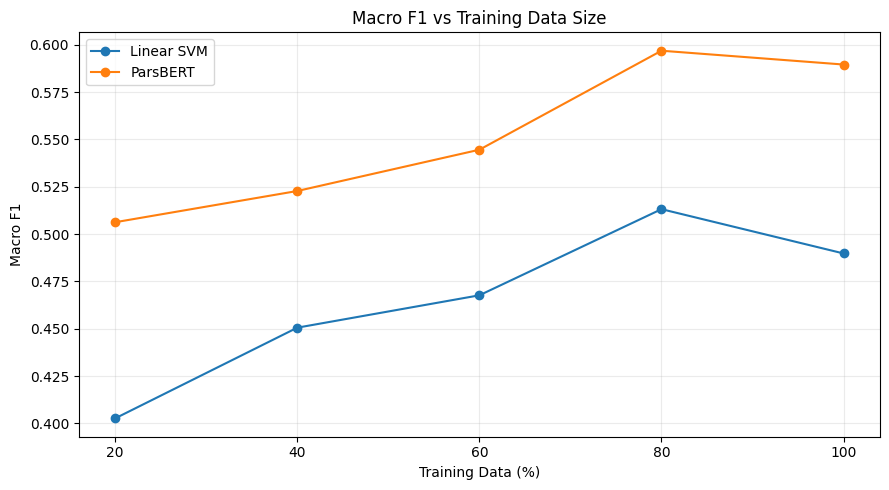

In [70]:
# Learning Curve Plot #

fig, ax = plt.subplots(
    figsize=(9, 5)
)


ax.plot(
    comparison_df[
        "Train Percentage"
    ],
    comparison_df[
        "Macro F1 SVM"
    ],
    marker="o",
    label="Linear SVM",
)


ax.plot(
    comparison_df[
        "Train Percentage"
    ],
    comparison_df[
        "Macro F1 ParsBERT"
    ],
    marker="o",
    label="ParsBERT",
)


ax.set_xlabel(
    "Training Data (%)"
)

ax.set_ylabel(
    "Macro F1"
)

ax.set_title(
    "Macro F1 vs Training Data Size"
)

ax.set_xticks(
    [
        20,
        40,
        60,
        80,
        100,
    ]
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

In [71]:
# Save Learning Curve Comparison #

comparison_df.to_csv(
    TABLES_DIR
    / "svm_vs_parsbert_learning_curve.csv",
    index=False,
)


fig.savefig(
    PLOTS_DIR
    / "svm_vs_parsbert_learning_curve.png",
    dpi=200,
    bbox_inches="tight",
)

## STEP 09 — Final Extended Findings

Summarizing the main observations from error analysis and learning curve experiments.


In [73]:
# Key Extended Findings #

top_directed = directed_confusions_df.iloc[0]

top_pair = pair_confusions_df.iloc[0]

best_parsbert_row = (
    parsbert_learning_curve_df.loc[
        parsbert_learning_curve_df[
            "Macro F1"
        ].idxmax()
    ]
)

best_svm_row = (
    svm_learning_curve_df.loc[
        svm_learning_curve_df[
            "Macro F1"
        ].idxmax()
    ]
)

largest_gap_row = (
    comparison_df.loc[
        comparison_df[
            "F1 Improvement"
        ].idxmax()
    ]
)

In [74]:
# Final Extended Summary #

extended_summary = {
    "Top Directed Confusion": (
        f"{top_directed['True Class']} → "
        f"{top_directed['Predicted Class']}"
    ),

    "Top Directed Confusion Count": int(
        top_directed["Count"]
    ),

    "Top Confused Class Pair": (
        f"{top_pair['Class A']} ↔ "
        f"{top_pair['Class B']}"
    ),

    "Top Pair Total Confusions": int(
        top_pair["Total Confusions"]
    ),

    "Best SVM Train Percentage": int(
        best_svm_row["Train Percentage"]
    ),

    "Best SVM Macro F1": float(
        best_svm_row["Macro F1"]
    ),

    "Best ParsBERT Train Percentage": int(
        best_parsbert_row["Train Percentage"]
    ),

    "Best ParsBERT Macro F1": float(
        best_parsbert_row["Macro F1"]
    ),

    "Largest ParsBERT Advantage At (%)": int(
        largest_gap_row["Train Percentage"]
    ),

    "Largest Macro F1 Advantage": float(
        largest_gap_row["F1 Improvement"]
    ),
}


extended_summary_df = pd.DataFrame(
    extended_summary.items(),
    columns=[
        "Finding",
        "Result",
    ],
)

extended_summary_df

,Finding,Result
0,Top Directed Confusion,happy → delighted
1,Top Directed Confusion Count,166
2,Top Confused Class Pair,neutral ↔ happy
3,Top Pair Total Confusions,304
4,Best SVM Train Percentage,80
5,Best SVM Macro F1,0.5132
6,Best ParsBERT Train Percentage,80
7,Best ParsBERT Macro F1,0.5969
8,Largest ParsBERT Advantage At (%),20
9,Largest Macro F1 Advantage,0.1036


In [75]:
final_learning_curve_df = comparison_df.copy()

final_learning_curve_df

,Train Percentage,Train Samples,Macro F1 SVM,Macro F1 ParsBERT,F1 Improvement
0,20,1835,0.4027,0.5063,0.1036
1,40,3668,0.4506,0.5228,0.0722
2,60,5501,0.4677,0.5446,0.0769
3,80,7334,0.5132,0.5969,0.0837
4,100,9165,0.4898,0.5896,0.0998


In [76]:
# Save Extended Analysis Summary #

extended_summary_df.to_csv(
    TABLES_DIR
    / "extended_analysis_summary.csv",
    index=False,
)

final_learning_curve_df.to_csv(
    TABLES_DIR
    / "final_learning_curve_comparison.csv",
    index=False,
)

print(
    "Extended analysis results saved."
)

Extended analysis results saved.


## Conclusion — Final Comparative Analysis

In this notebook, the final ParsBERT and Linear SVM results were analyzed through confusion patterns, manual error inspection, and learning curve experiments. These analyses provide a deeper understanding of model behavior beyond standard evaluation metrics.

**Next step:** The complete SentiPers sentiment analysis pipeline is now finished, including auditing, cleaning, classic machine learning models, ParsBERT Fine-tuning, and extended evaluation analysis.
